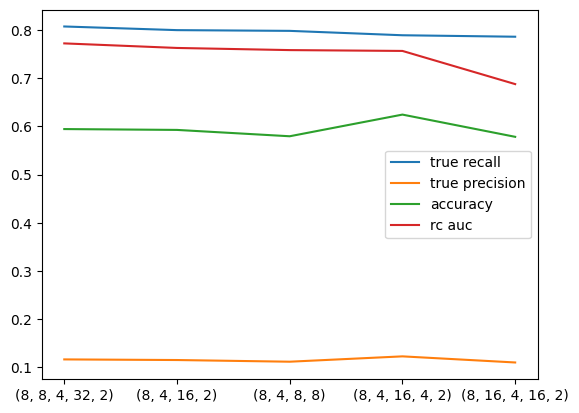

In [ ]:
df = pd.read_csv('/home/server/Projects/data/AKI/dnn_grid_search_performance.csv')
df_sorted = df.sort_values(by='true recall', ascending=False).iloc[15:20,:]
shapes_sorted = df_sorted['shape']

# plt.plot(df_sorted['true precision'])
# plt.plot(df_sorted['true recall'])
# plt.plot(df_sorted['rc_auc'])

plt.plot(shapes_sorted, df_sorted['true recall'], label='true recall')
plt.plot(shapes_sorted, df_sorted['true precision'], label='true precision')
plt.plot(shapes_sorted, df_sorted['acc'], label='accuracy')
plt.plot(shapes_sorted, df_sorted['rc_auc'], label='rc auc')
plt.legend()
plt.show()

In [18]:
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import pandas as pd
import torch
import os
from torch import nn
from torch.utils.data import Dataset, DataLoader

file = "/home/server/Projects/data/AKI/tabular_combined.npz"

with np.load(file, allow_pickle=True) as data:
    X_train=torch.from_numpy(data["X_train"].astype(float))
    X_test=torch.from_numpy(data["X_test"].astype(float))
    y_train=torch.from_numpy(data["y_train"].astype(float))
    y_test=torch.from_numpy(data["y_test"].astype(float))
    y_binary_train=torch.from_numpy(data["y_binary_train"].astype(float))
    y_binary_test=torch.from_numpy(data["y_binary_test"].astype(float))

TypeError: can't convert np.ndarray of type numpy.object_. The only supported types are: float64, float32, float16, complex64, complex128, int64, int32, int16, int8, uint64, uint32, uint16, uint8, and bool.

In [ ]:


device = torch.device('cuda')
X_train = torch.Tensor(X_train.astype(float))
y_binary_train = torch.Tensor(y_binary_train.astype(float))

X_train=data["X_train"]
X_test=data["X_test"]
y_train=data["y_train"]
y_test=data["y_test"]
y_binary_train=data["y_binary_train"]
y_binary_test=data["y_binary_test"]

In [ ]:
class AKIDataSet(Dataset):
    def __init__(self, data, target):
    #     if type(data) == np.ndarray:
    #         data = torch.from_numpy(data)
    #     if type(target) == np.ndarray:
    #         target = torch.from_numpy(target)
        self.data = data.to(dtype=torch.float32)
        self.target = torch.flatten(target.to(dtype=torch.float32))
    def __len__(self):
        return self.data.shape[0]
    def __getitem__(self, idx):
        return self.data[idx], self.target[idx]

NameError: name 'Dataset' is not defined

In [ ]:
self.linear_relu_stack = nn.Sequential()
        prev = input_size
        for dim in hidden_layer_sizes:
            self.linear_relu_stack.append(nn.Linear(prev, dim))
            self.linear_relu_stack.append(nn.ReLU())
            prev = dim
        self.linear_relu_stack.append(nn.Linear(prev, 1))
        self.linear_relu_stack.append(nn.Sigmoid())
        self.linear_relu_stack = self.linear_relu_stack.to(device)

In [9]:
architectures = [  (32, 64, 128, 32)]
    # (8, 8, 4, 32, 2),]
                    # (8, 4, 16, 2),
                    # (8, 4, 8, 8),
                    # (8, 4, 16, 4, 2),
                    # (8, 16, 4, 16, 2)]

y_pred = []


for arch in architectures:
    model = DNN(hidden_layer_sizes=arch).to(device)
    model.train(True)

    dataloader = DataLoader(AKIDataSet(X_train, y_binary_train), batch_size=64, shuffle=True, num_workers=(os.cpu_count() - 1))
    loss_fn   = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    num_epochs = 300
    prev_loss = 10000


    for epoch in range(num_epochs):
        # if epoch == num_epochs - 1:
            # for batch_idx, (inputs, targets) in enumerate(dataloader):
            #     # Forward pass
            #     inputs = inputs.to(device)
            #     targets = targets.to(device)
            #     outputs = model(inputs)
            #     y_pred.extend(outputs)
            #     loss = loss_fn(targets, outputs)
            #     # if abs(loss - prev_loss) / prev_loss < 0.001:
            #     #     break
            #     # prev_loss = loss
            #     # Backward pass and optimization
            #     optimizer.zero_grad()
            #     loss.backward()
            #     optimizer.step()
        # else:
        for batch_idx, (inputs, targets) in enumerate(dataloader):
            # Forward pass
            inputs = inputs.to(device)
            targets = targets.to(device)
            outputs = model(inputs)
            loss = loss_fn(outputs, targets.unsqueeze(1))
            # if abs(loss - prev_loss) / prev_loss < 0.001:
            #     break
            # prev_loss = loss
            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")


Epoch [1/300], Loss: 0.6521
Epoch [2/300], Loss: 0.5707
Epoch [3/300], Loss: 0.6316
Epoch [4/300], Loss: 0.6100
Epoch [5/300], Loss: 0.6559
Epoch [6/300], Loss: 0.6176
Epoch [7/300], Loss: 0.6508
Epoch [8/300], Loss: 0.6533
Epoch [9/300], Loss: 0.5940
Epoch [10/300], Loss: 0.6331
Epoch [11/300], Loss: 0.6055
Epoch [12/300], Loss: 0.5746
Epoch [13/300], Loss: 0.6343
Epoch [14/300], Loss: 0.6682
Epoch [15/300], Loss: 0.5579
Epoch [16/300], Loss: 0.5626
Epoch [17/300], Loss: 0.5938
Epoch [18/300], Loss: 0.6057
Epoch [19/300], Loss: 0.5608
Epoch [20/300], Loss: 0.6102
Epoch [21/300], Loss: 0.5228
Epoch [22/300], Loss: 0.5033
Epoch [23/300], Loss: 0.6220
Epoch [24/300], Loss: 0.5952
Epoch [25/300], Loss: 0.6563
Epoch [26/300], Loss: 0.5891
Epoch [27/300], Loss: 0.6094
Epoch [28/300], Loss: 0.6174
Epoch [29/300], Loss: 0.5627
Epoch [30/300], Loss: 0.6342
Epoch [31/300], Loss: 0.6057
Epoch [32/300], Loss: 0.6463
Epoch [33/300], Loss: 0.6595
Epoch [34/300], Loss: 0.6531
Epoch [35/300], Loss: 0

In [3]:
def performance(y_binary_test, y_pred, y_prob, plot=True):
    accuracy = accuracy_score(y_binary_test, y_pred)
    print(f'Accuracy: {accuracy:.2f}')

    cm = confusion_matrix(y_binary_test, y_pred)
    print('Confusion Matrix:')
    print(cm)

    report = classification_report(y_binary_test, y_pred)
    print('Classification Report:')
    print(report)

    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(y_binary_test, y_prob)
    roc_auc = auc(fpr, tpr)

    # Compute PR curve
    # fpr, tpr, thresholds = roc_curve(y_binary_test, y_prob)
    # roc_auc = auc(fpr, tpr)
    prec, rec, thresholds = precision_recall_curve(y_binary_test, y_prob)
    pr_auc = auc(rec, prec)

    # Plot ROC curve
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc='lower right')
    plt.show()

    # Plot PR curve
    plt.figure()
    plt.plot(prec, rec, color='yellow', lw=2, label=f'PR curve (area = {pr_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('precision')
    plt.ylabel('recall')
    plt.title('Precision-Recall Curve')
    plt.legend(loc='lower right')
    plt.show()
    return report, roc_auc, average_precision_score

def performance_dict(y_binary_test, y_pred, y_prob, plot=True):
    rtn = {}
    report = classification_report(y_binary_test, y_pred, output_dict=True)
    for key, value in report['False'].items():
        rtn["false " + key] = value
    for key, value in report['True'].items():
        rtn["true " + key] = value
    # print('Classification Report:')
    # print(report)

    rtn["acc"] = accuracy_score(y_binary_test, y_pred)
    # print(f'Accuracy: {rtn["acc"]:.2f}')

    # report["cm"] = confusion_matrix(y_binary_test, y_pred)
    # print('Confusion Matrix:')
    # print(report["cm"])

    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(y_binary_test, y_prob)
    rtn["rc_auc"] = auc(fpr, tpr)
    # print(rtn["rc_auc"])


    # Compute PR curve
    prec, rec, thresholds = precision_recall_curve(y_binary_test, y_prob)
    rtn["pr_auc"] = auc(rec, prec)
    # print(rtn["pr_auc"])


    return rtn
# new_dict = performance_dict(y_binary_test, y_pred, y_prob)
# new_dict

In [ ]:
true_precisions = []
true_recalls = []
accs = []
aucs = []
all_data = pd.DataFrame(columns = ('shape',
                            'false precision',
                            'false recall',
                            'false f1-score',
                            'false support',
                            'true precision',
                            'true recall',
                            'true f1-score',
                            'true support',
                            'acc',
                            'rc_auc',
                            'pr_auc'))
all_data

,shape,false precision,false recall,false f1-score,false support,true precision,true recall,true f1-score,true support,acc,rc_auc,pr_auc


In [ ]:
architectures_z = archits
for arch in architectures_z:
    model = MLPClassifier(random_state=42, max_iter=1000, hidden_layer_sizes=arch)
    model.fit(X_train, y_binary_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    report = performance_dict(y_binary_test, y_pred, y_prob)
    report['shape'] = str(arch)
    all_data.loc[len(all_data)] = report
    all_data.to_csv('/home/server/Projects/data/AKI/dnn_grid_search_performance.csv')

/home/server/Projects/VitalDB-Dimensionality-Reduction/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/server/Projects/VitalDB-Dimensionality-Reduction/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/server/Projects/VitalDB-Dimensionality-Reduction/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` paramete

In [ ]:
all_data

,shape,false precision,false recall,false f1-score,false support,true precision,true recall,true f1-score,true support,acc,rc_auc,pr_auc
0,10,0.968161,0.760525,0.851873,9596.0,0.154214,0.635812,0.248223,659.0,0.752511,0.772559,0.224532
1,"(20, 40)",0.959687,0.791371,0.867440,9596.0,0.145175,0.515933,0.226591,659.0,0.773671,0.724518,0.163198


,Unnamed: 0,shape,false precision,false recall,false f1-score,false support,true precision,true recall,true f1-score,true support,acc,rc_auc,pr_auc
0,0,"(32, 8, 4, 16)",0.963031,0.765527,0.852996,9596.0,0.143510,0.572079,0.229458,659.0,0.753096,0.718562,0.160963
1,1,"(32, 8, 4, 16, 2)",0.961323,0.787411,0.865720,9596.0,0.148225,0.538695,0.232482,659.0,0.771429,0.707292,0.123175
2,2,"(4, 32, 8, 16)",0.973269,0.656419,0.784043,9596.0,0.128469,0.737481,0.218820,659.0,0.661628,0.765128,0.228100
3,3,"(4, 32, 8, 16, 2)",0.935739,1.000000,0.966803,9596.0,0.000000,0.000000,0.000000,659.0,0.935739,0.500000,0.532131
4,4,"(32, 16, 32)",0.956636,0.834514,0.891412,9596.0,0.157113,0.449165,0.232796,659.0,0.809751,0.706394,0.137759
...,...,...,...,...,...,...,...,...,...,...,...,...,...
675,675,"(32, 4, 8, 16, 2)",0.946667,0.961859,0.954202,9596.0,0.275248,0.210926,0.238832,659.0,0.913603,0.588476,0.260392
676,676,"(16, 8, 32, 8)",0.962632,0.740934,0.837357,9596.0,0.133496,0.581184,0.217120,659.0,0.730668,0.716715,0.174210
677,677,"(16, 8, 32, 8, 2)",0.964575,0.706544,0.815639,9596.0,0.127092,0.622155,0.211068,659.0,0.701121,0.719729,0.210009
678,678,"(4, 8, 8, 4)",0.972095,0.707899,0.819223,9596.0,0.142026,0.704097,0.236373,659.0,0.707655,0.773546,0.219458


In [ ]:
# archits = []
# nums = [0, 4, 8, 16, 32]
# for i in nums[1:]:
#     for j in nums:
#         for k in nums:
#             for l in nums:
#                 archits.append(tuple([digit for digit in [i, j, k, l] if digit != 0]))

In [ ]:
temp = []
for archit in archits:
    temp.append(archit)
    temp.append(tuple((*archit, 2)))

In [ ]:
archits = temp

Accuracy: 0.86
Confusion Matrix:
[[8607  989]
 [ 488  171]]
Classification Report:
              precision    recall  f1-score   support

       False       0.95      0.90      0.92      9596
        True       0.15      0.26      0.19       659

    accuracy                           0.86     10255
   macro avg       0.55      0.58      0.55     10255
weighted avg       0.90      0.86      0.87     10255



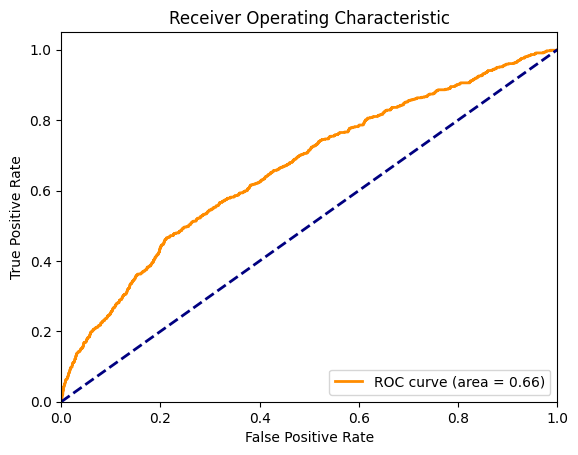

Accuracy: 0.88
Confusion Matrix:
[[8883  713]
 [ 513  146]]
Classification Report:
              precision    recall  f1-score   support

       False       0.95      0.93      0.94      9596
        True       0.17      0.22      0.19       659

    accuracy                           0.88     10255
   macro avg       0.56      0.57      0.56     10255
weighted avg       0.90      0.88      0.89     10255



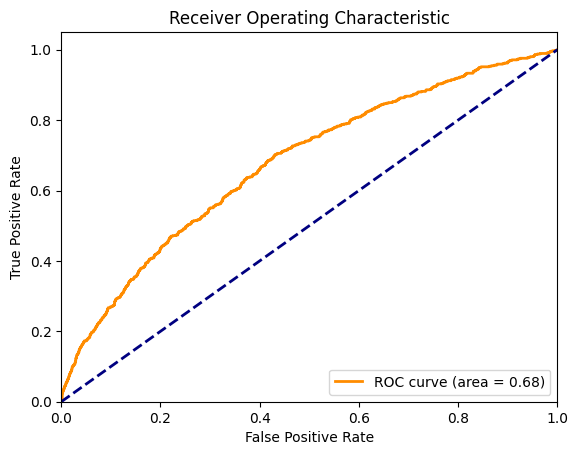

Accuracy: 0.85
Confusion Matrix:
[[8552 1044]
 [ 443  216]]
Classification Report:
              precision    recall  f1-score   support

       False       0.95      0.89      0.92      9596
        True       0.17      0.33      0.23       659

    accuracy                           0.85     10255
   macro avg       0.56      0.61      0.57     10255
weighted avg       0.90      0.85      0.88     10255



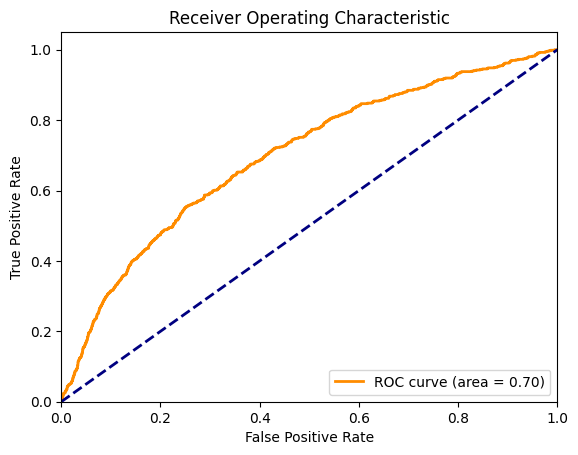

Accuracy: 0.80
Confusion Matrix:
[[7874 1722]
 [ 367  292]]
Classification Report:
              precision    recall  f1-score   support

       False       0.96      0.82      0.88      9596
        True       0.14      0.44      0.22       659

    accuracy                           0.80     10255
   macro avg       0.55      0.63      0.55     10255
weighted avg       0.90      0.80      0.84     10255



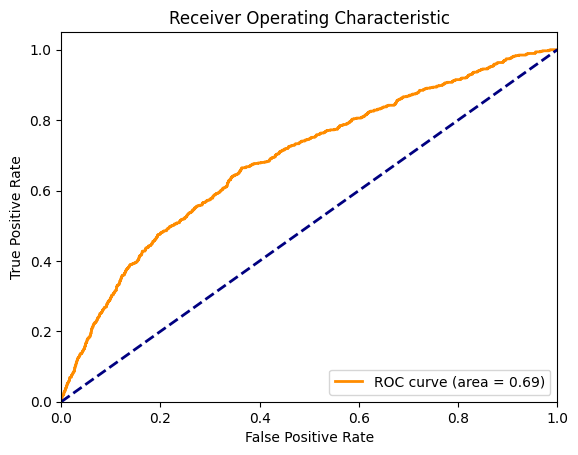

In [ ]:
architectures = [(100,), (50, 50,), (50, 30, 20,), (30, 20, 30, 20)]
for arch in architectures:
    model = MLPClassifier(random_state=42, max_iter=1000, hidden_layer_sizes=arch)
    model.fit(X_train, y_binary_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    report, roc_auc = performance(y_binary_test, y_pred, y_prob)

    tokens = report.split()
    true_precisions.append(float(tokens[10]))
    true_recalls.append(float(tokens[11]))
    accs.append(float(tokens[15]))
    aucs.append(roc_auc)

Accuracy: 0.79
Confusion Matrix:
[[7751 1845]
 [ 340  319]]
Classification Report:
              precision    recall  f1-score   support

       False       0.96      0.81      0.88      9596
        True       0.15      0.48      0.23       659

    accuracy                           0.79     10255
   macro avg       0.55      0.65      0.55     10255
weighted avg       0.91      0.79      0.83     10255



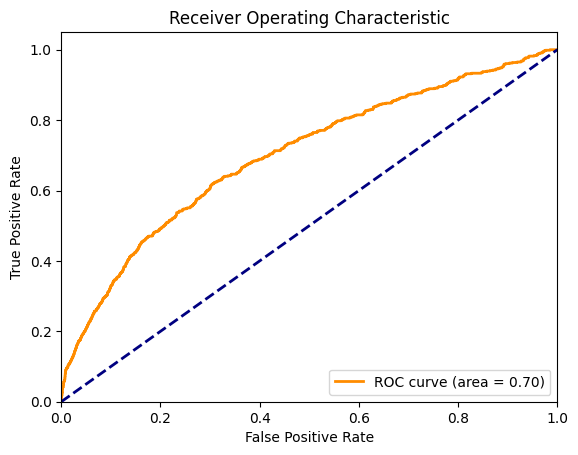

Accuracy: 0.87
Confusion Matrix:
[[8781  815]
 [ 501  158]]
Classification Report:
              precision    recall  f1-score   support

       False       0.95      0.92      0.93      9596
        True       0.16      0.24      0.19       659

    accuracy                           0.87     10255
   macro avg       0.55      0.58      0.56     10255
weighted avg       0.90      0.87      0.88     10255



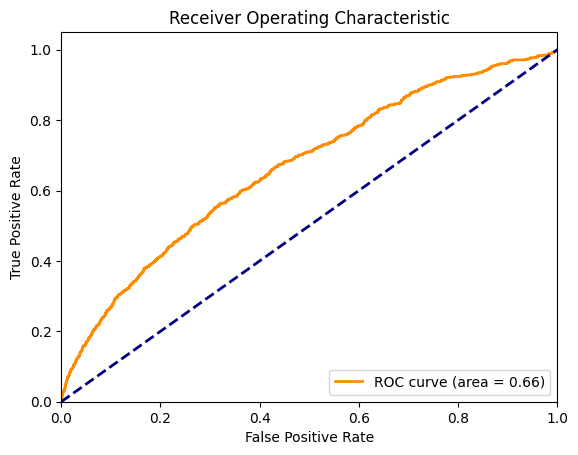

Accuracy: 0.84
Confusion Matrix:
[[8367 1229]
 [ 413  246]]
Classification Report:
              precision    recall  f1-score   support

       False       0.95      0.87      0.91      9596
        True       0.17      0.37      0.23       659

    accuracy                           0.84     10255
   macro avg       0.56      0.62      0.57     10255
weighted avg       0.90      0.84      0.87     10255



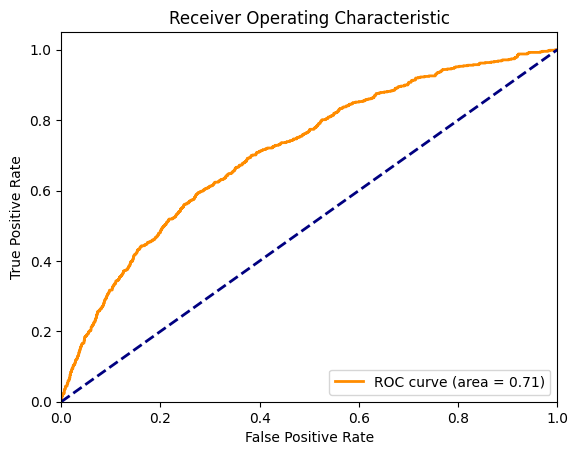

Accuracy: 0.79
Confusion Matrix:
[[7768 1828]
 [ 337  322]]
Classification Report:
              precision    recall  f1-score   support

       False       0.96      0.81      0.88      9596
        True       0.15      0.49      0.23       659

    accuracy                           0.79     10255
   macro avg       0.55      0.65      0.55     10255
weighted avg       0.91      0.79      0.84     10255



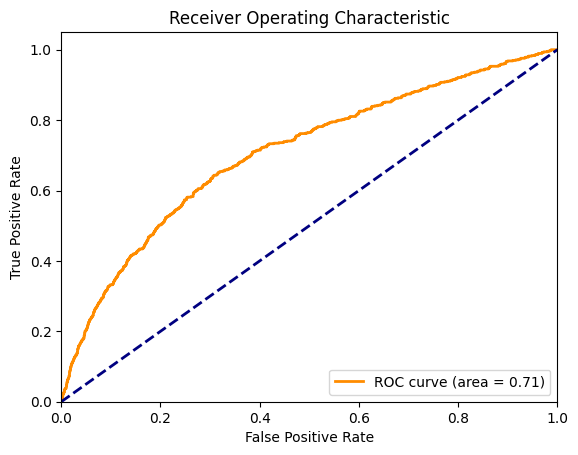

Accuracy: 0.77
Confusion Matrix:
[[7532 2064]
 [ 297  362]]
Classification Report:
              precision    recall  f1-score   support

       False       0.96      0.78      0.86      9596
        True       0.15      0.55      0.23       659

    accuracy                           0.77     10255
   macro avg       0.56      0.67      0.55     10255
weighted avg       0.91      0.77      0.82     10255



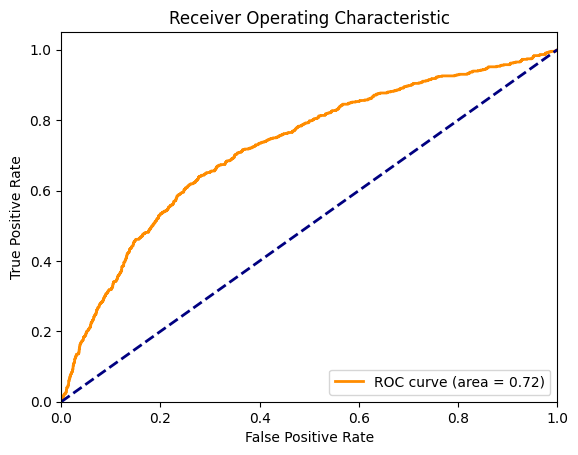

In [ ]:
architectures_2 = [(50,), (75, 25,), (25, 75,), (20, 20, 20,), (30, 10, 30, 20)]
for arch in architectures_2:
    model = MLPClassifier(random_state=42, max_iter=1000, hidden_layer_sizes=arch)
    model.fit(X_train, y_binary_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    report, roc_auc = performance(y_binary_test, y_pred, y_prob)

    tokens = report.split()
    true_precisions.append(float(tokens[10]))
    true_recalls.append(float(tokens[11]))
    accs.append(float(tokens[15]))
    aucs.append(roc_auc)

Accuracy: 0.75
Confusion Matrix:
[[7298 2298]
 [ 240  419]]
Classification Report:
              precision    recall  f1-score   support

       False       0.97      0.76      0.85      9596
        True       0.15      0.64      0.25       659

    accuracy                           0.75     10255
   macro avg       0.56      0.70      0.55     10255
weighted avg       0.92      0.75      0.81     10255



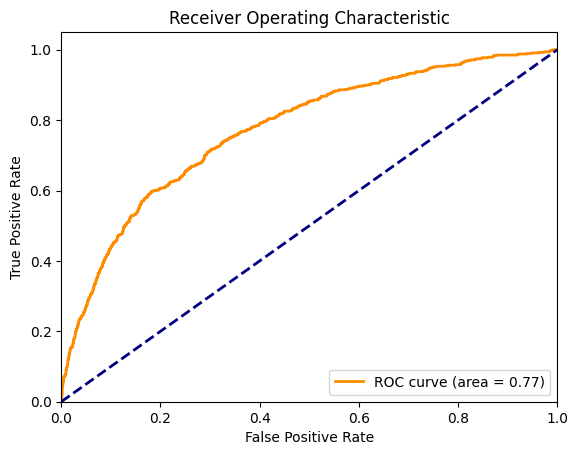

Accuracy: 0.76
Confusion Matrix:
[[7455 2141]
 [ 273  386]]
Classification Report:
              precision    recall  f1-score   support

       False       0.96      0.78      0.86      9596
        True       0.15      0.59      0.24       659

    accuracy                           0.76     10255
   macro avg       0.56      0.68      0.55     10255
weighted avg       0.91      0.76      0.82     10255



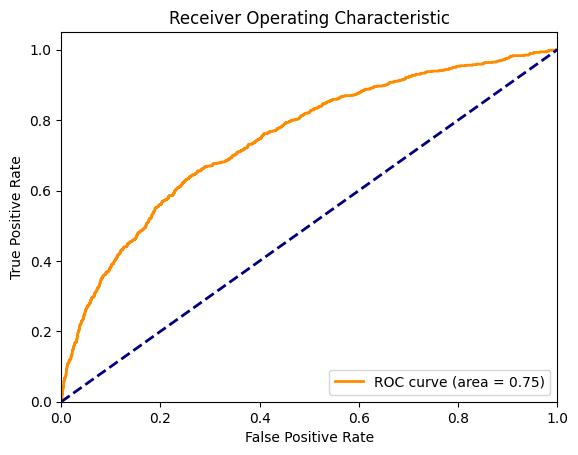

Accuracy: 0.71
Confusion Matrix:
[[6865 2731]
 [ 241  418]]
Classification Report:
              precision    recall  f1-score   support

       False       0.97      0.72      0.82      9596
        True       0.13      0.63      0.22       659

    accuracy                           0.71     10255
   macro avg       0.55      0.67      0.52     10255
weighted avg       0.91      0.71      0.78     10255



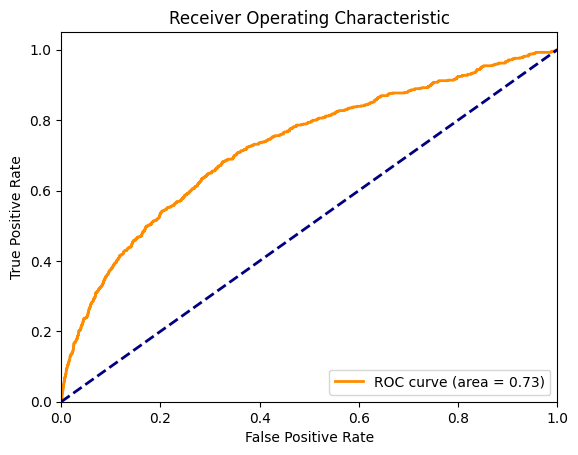

Accuracy: 0.73
Confusion Matrix:
[[7064 2532]
 [ 254  405]]
Classification Report:
              precision    recall  f1-score   support

       False       0.97      0.74      0.84      9596
        True       0.14      0.61      0.23       659

    accuracy                           0.73     10255
   macro avg       0.55      0.68      0.53     10255
weighted avg       0.91      0.73      0.80     10255



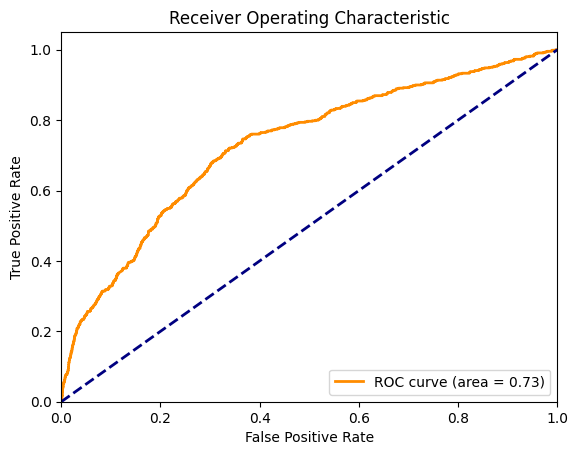

Accuracy: 0.72
Confusion Matrix:
[[7038 2558]
 [ 267  392]]
Classification Report:
              precision    recall  f1-score   support

       False       0.96      0.73      0.83      9596
        True       0.13      0.59      0.22       659

    accuracy                           0.72     10255
   macro avg       0.55      0.66      0.53     10255
weighted avg       0.91      0.72      0.79     10255



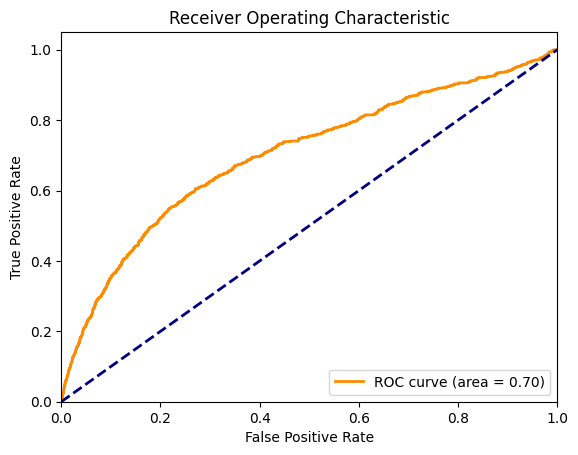

In [ ]:
architectures_3 = [(10,), (25), (20, 10, 20,), (20, 5, 20, 10), (20, 10, 20, 10, 20)]
for arch in architectures_3:
    model = MLPClassifier(random_state=42, max_iter=1000, hidden_layer_sizes=arch)
    model.fit(X_train, y_binary_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    report, roc_auc = performance(y_binary_test, y_pred, y_prob)

    tokens = report.split()
    true_precisions.append(float(tokens[10]))
    true_recalls.append(float(tokens[11]))
    accs.append(float(tokens[15]))
    aucs.append(roc_auc)

Accuracy: 0.85
Confusion Matrix:
[[8530 1066]
 [ 438  221]]
Classification Report:
              precision    recall  f1-score   support

       False       0.95      0.89      0.92      9596
        True       0.17      0.34      0.23       659

    accuracy                           0.85     10255
   macro avg       0.56      0.61      0.57     10255
weighted avg       0.90      0.85      0.87     10255



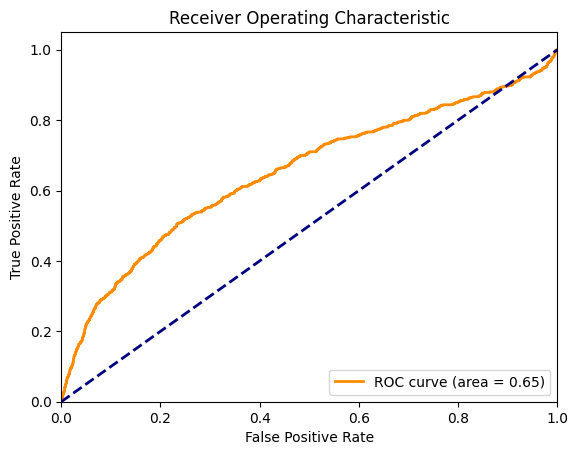

Accuracy: 0.84
Confusion Matrix:
[[8314 1282]
 [ 410  249]]
Classification Report:
              precision    recall  f1-score   support

       False       0.95      0.87      0.91      9596
        True       0.16      0.38      0.23       659

    accuracy                           0.84     10255
   macro avg       0.56      0.62      0.57     10255
weighted avg       0.90      0.84      0.86     10255



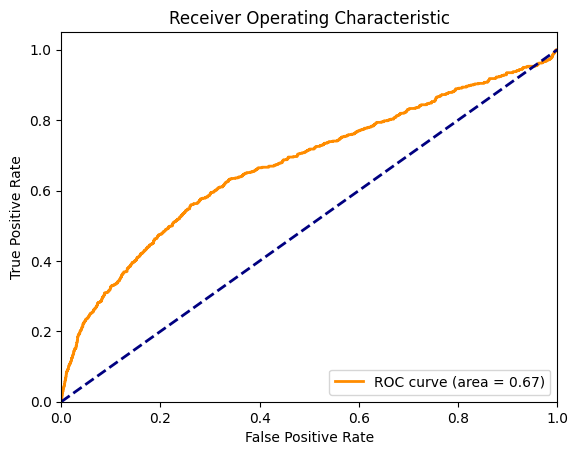

Accuracy: 0.73
Confusion Matrix:
[[7161 2435]
 [ 321  338]]
Classification Report:
              precision    recall  f1-score   support

       False       0.96      0.75      0.84      9596
        True       0.12      0.51      0.20       659

    accuracy                           0.73     10255
   macro avg       0.54      0.63      0.52     10255
weighted avg       0.90      0.73      0.80     10255



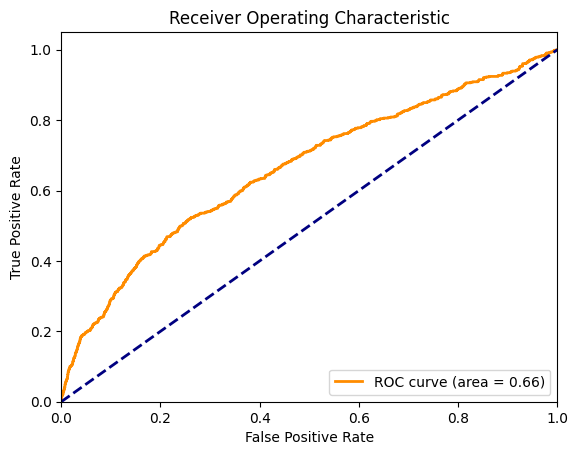

Accuracy: 0.79
Confusion Matrix:
[[7814 1782]
 [ 344  315]]
Classification Report:
              precision    recall  f1-score   support

       False       0.96      0.81      0.88      9596
        True       0.15      0.48      0.23       659

    accuracy                           0.79     10255
   macro avg       0.55      0.65      0.55     10255
weighted avg       0.91      0.79      0.84     10255



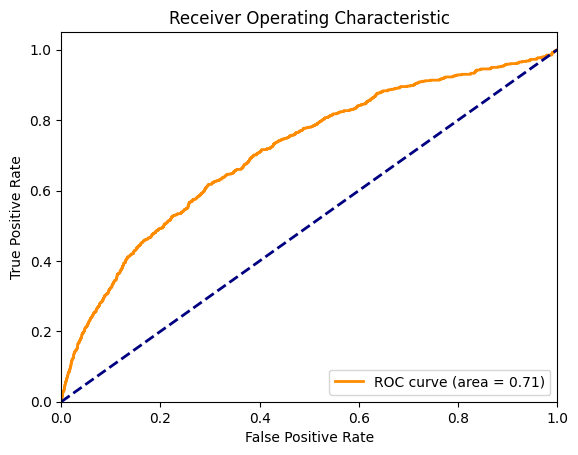

In [ ]:
from sklearn.neural_network import MLPRegressor
architectures_4 = [(100, 25), (50, 50), (50), (20, 10, 20,)]
for arch in architectures_4:
    model = MLPRegressor(random_state=42, max_iter=10000, hidden_layer_sizes=arch)
    model.fit(X_train_smote, y_train_smote)

    y_pred = model.predict(X_test)
    y_pred_binary = y_pred > 0.3
    y_pred_range = max(y_pred) - min(y_pred)
    y_pred_min = min(y_pred)
    y_pred = (y_pred - y_pred_min) / y_pred_range
    report, roc_auc = performance(y_binary_test, y_pred_binary, y_pred)

Accuracy: 0.81
Confusion Matrix:
[[8053 1543]
 [ 395  264]]
Classification Report:
              precision    recall  f1-score   support

       False       0.95      0.84      0.89      9596
        True       0.15      0.40      0.21       659

    accuracy                           0.81     10255
   macro avg       0.55      0.62      0.55     10255
weighted avg       0.90      0.81      0.85     10255



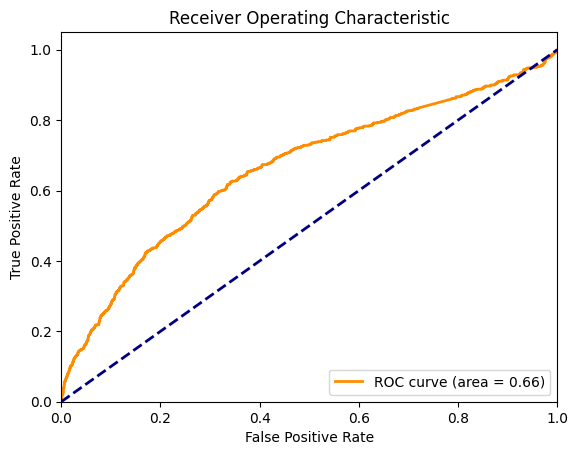

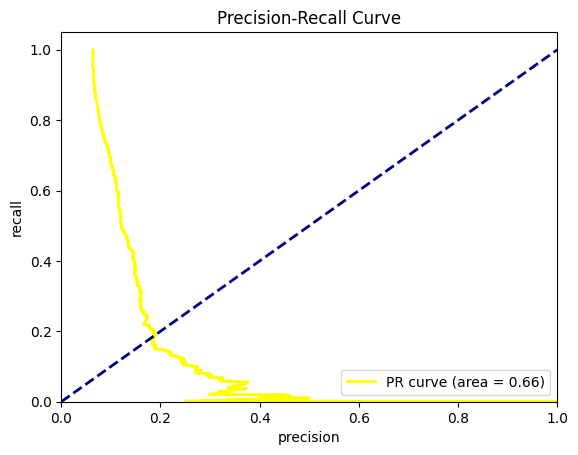

Accuracy: 0.83
Confusion Matrix:
[[8223 1373]
 [ 416  243]]
Classification Report:
              precision    recall  f1-score   support

       False       0.95      0.86      0.90      9596
        True       0.15      0.37      0.21       659

    accuracy                           0.83     10255
   macro avg       0.55      0.61      0.56     10255
weighted avg       0.90      0.83      0.86     10255



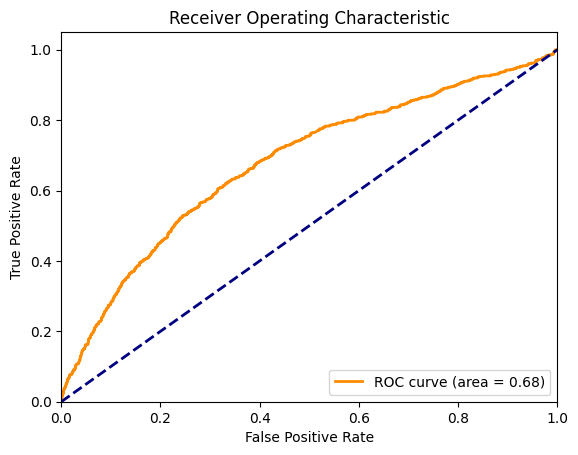

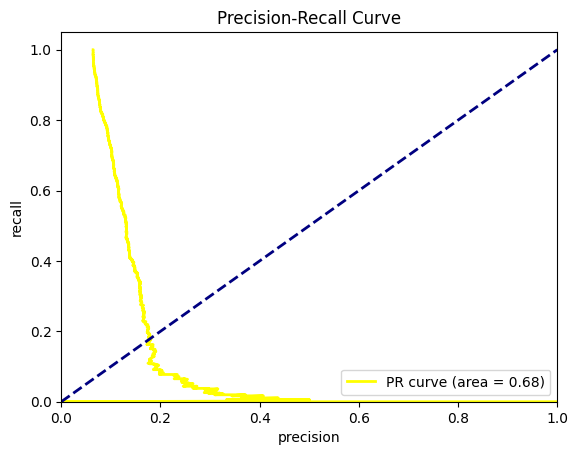

Accuracy: 0.82
Confusion Matrix:
[[8154 1442]
 [ 379  280]]
Classification Report:
              precision    recall  f1-score   support

       False       0.96      0.85      0.90      9596
        True       0.16      0.42      0.24       659

    accuracy                           0.82     10255
   macro avg       0.56      0.64      0.57     10255
weighted avg       0.90      0.82      0.86     10255



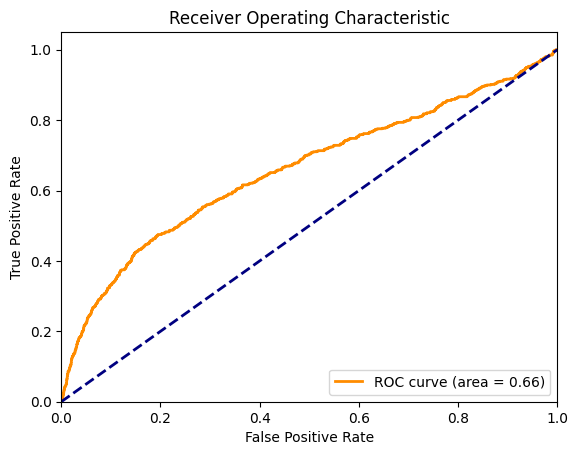

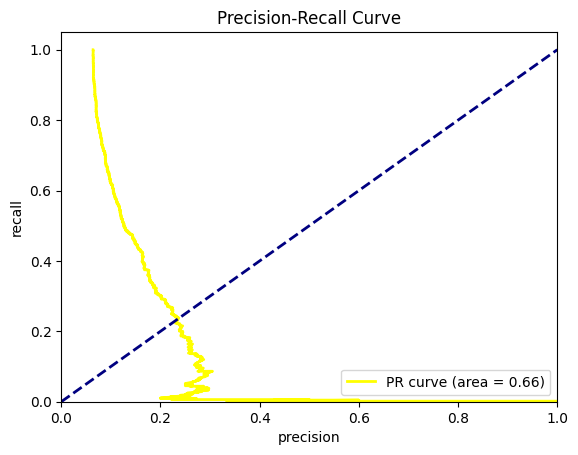

Accuracy: 0.72
Confusion Matrix:
[[7037 2559]
 [ 333  326]]
Classification Report:
              precision    recall  f1-score   support

       False       0.95      0.73      0.83      9596
        True       0.11      0.49      0.18       659

    accuracy                           0.72     10255
   macro avg       0.53      0.61      0.51     10255
weighted avg       0.90      0.72      0.79     10255



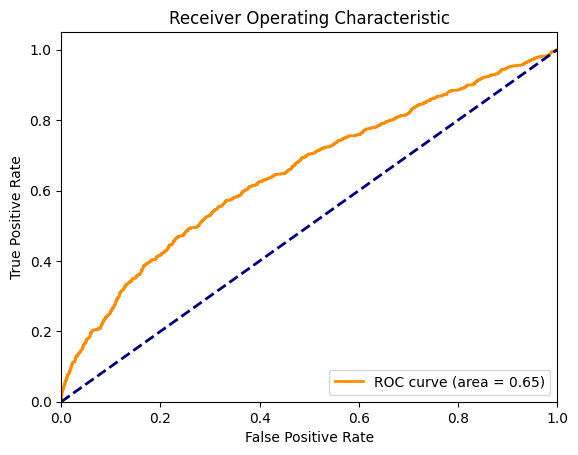

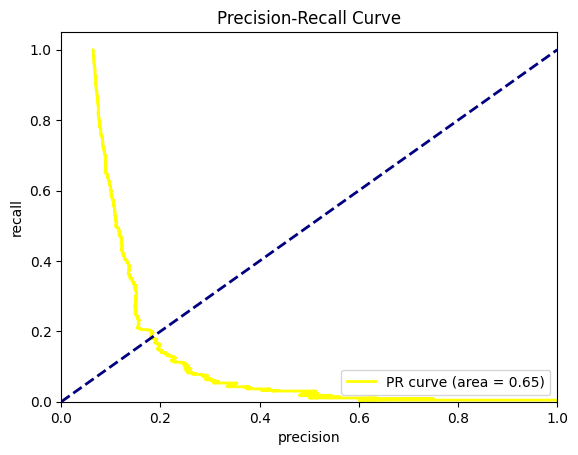

Accuracy: 0.69
Confusion Matrix:
[[6636 2960]
 [ 232  427]]
Classification Report:
              precision    recall  f1-score   support

       False       0.97      0.69      0.81      9596
        True       0.13      0.65      0.21       659

    accuracy                           0.69     10255
   macro avg       0.55      0.67      0.51     10255
weighted avg       0.91      0.69      0.77     10255



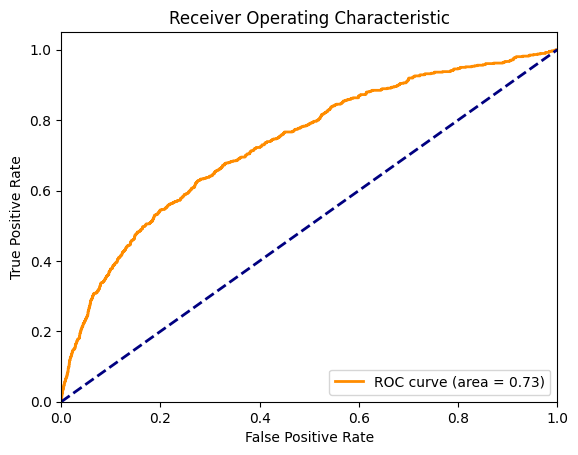

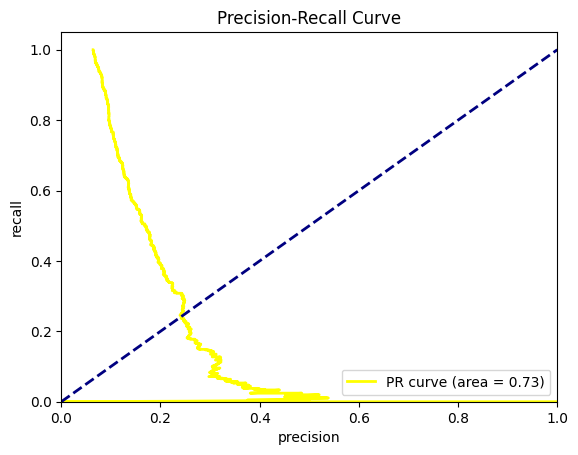

Accuracy: 0.71
Confusion Matrix:
[[6909 2687]
 [ 274  385]]
Classification Report:
              precision    recall  f1-score   support

       False       0.96      0.72      0.82      9596
        True       0.13      0.58      0.21       659

    accuracy                           0.71     10255
   macro avg       0.54      0.65      0.51     10255
weighted avg       0.91      0.71      0.78     10255



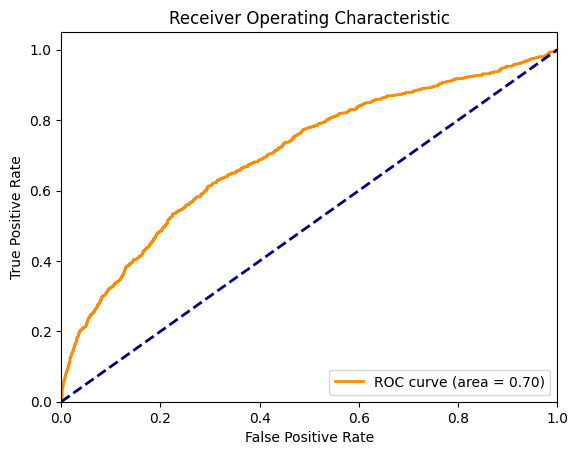

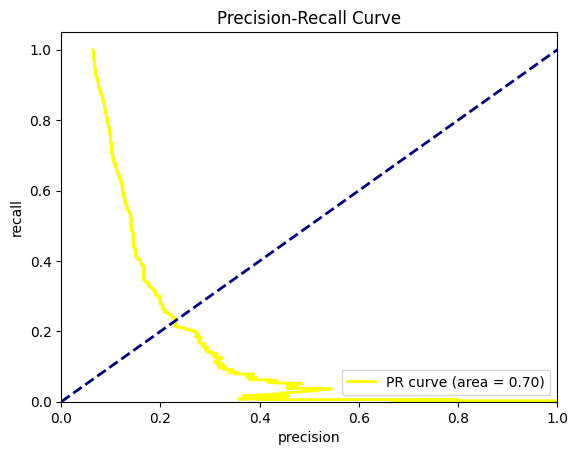

Accuracy: 0.81
Confusion Matrix:
[[8053 1543]
 [ 395  264]]
Classification Report:
              precision    recall  f1-score   support

       False       0.95      0.84      0.89      9596
        True       0.15      0.40      0.21       659

    accuracy                           0.81     10255
   macro avg       0.55      0.62      0.55     10255
weighted avg       0.90      0.81      0.85     10255



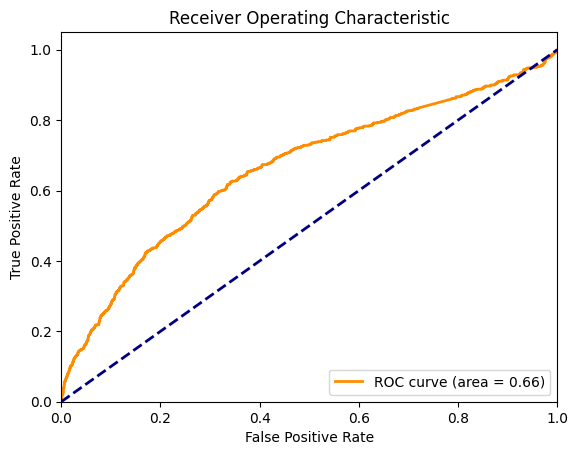

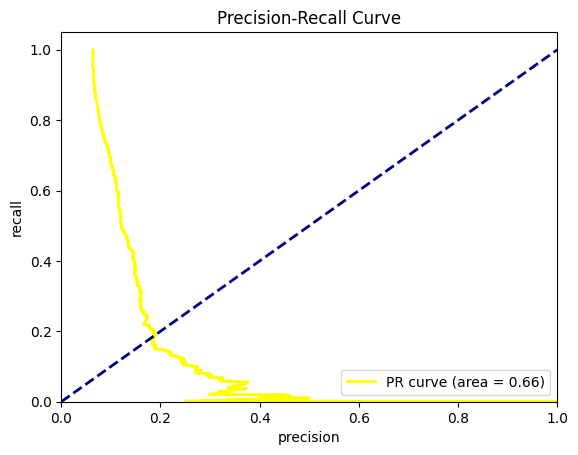

In [ ]:
from sklearn.neural_network import MLPRegressor #(50, 50) is best? Test of nonsmoted data, using regressor instead of classifier
architectures_4 = [(20, 10, 20,), (30, 10, 30, 20), (50, 50), (50), (10,), (25), (20, 10, 20,)]
for arch in architectures_4:
    model = MLPRegressor(random_state=42, max_iter=10000, hidden_layer_sizes=arch)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_pred_binary = y_pred > 0.3
    y_pred_range = max(y_pred) - min(y_pred)
    y_pred_min = min(y_pred)
    y_pred = (y_pred - y_pred_min) / y_pred_range
    report, roc_auc = performance(y_binary_test, y_pred_binary, y_pred)
    
    tokens = report.split()
    true_precisions.append(float(tokens[10]))
    true_recalls.append(float(tokens[11]))
    accs.append(float(tokens[15]))
    aucs.append(roc_auc)

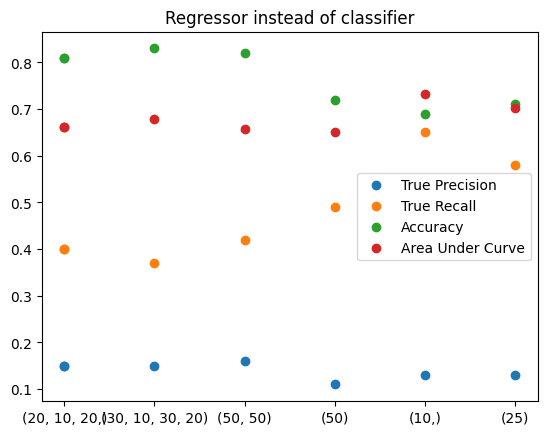

In [ ]:
arch_labels = ["(20, 10, 20,)", "(30, 10, 30, 20)", "(50, 50)", "(50)", "(10,)", "(25)", "(20, 10, 20,)"]

plt.scatter(arch_labels, true_precisions, label = "True Precision")
plt.scatter(arch_labels, true_recalls, label = "True Recall")
plt.scatter(arch_labels, accs, label = "Accuracy")
plt.scatter(arch_labels, aucs, label = "Area Under Curve")
plt.legend()
plt.title("Regressor instead of classifier")
plt.show()

Accuracy: 0.87
Confusion Matrix:
[[8739  857]
 [ 491  168]]
Classification Report:
              precision    recall  f1-score   support

       False       0.95      0.91      0.93      9596
        True       0.16      0.25      0.20       659

    accuracy                           0.87     10255
   macro avg       0.56      0.58      0.56     10255
weighted avg       0.90      0.87      0.88     10255



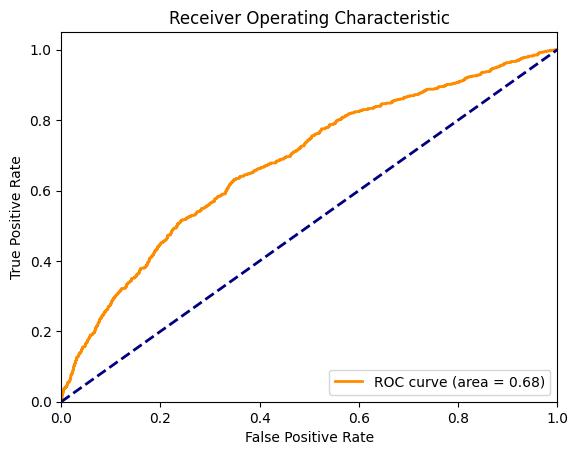

Accuracy: 0.86
Confusion Matrix:
[[8560 1036]
 [ 444  215]]
Classification Report:
              precision    recall  f1-score   support

       False       0.95      0.89      0.92      9596
        True       0.17      0.33      0.23       659

    accuracy                           0.86     10255
   macro avg       0.56      0.61      0.57     10255
weighted avg       0.90      0.86      0.88     10255



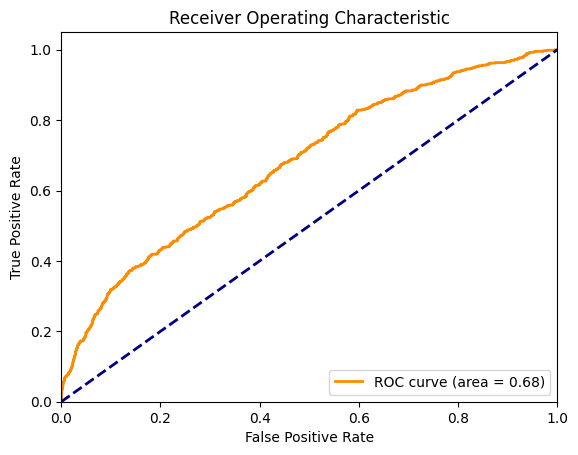

Accuracy: 0.83
Confusion Matrix:
[[8320 1276]
 [ 417  242]]
Classification Report:
              precision    recall  f1-score   support

       False       0.95      0.87      0.91      9596
        True       0.16      0.37      0.22       659

    accuracy                           0.83     10255
   macro avg       0.56      0.62      0.56     10255
weighted avg       0.90      0.83      0.86     10255



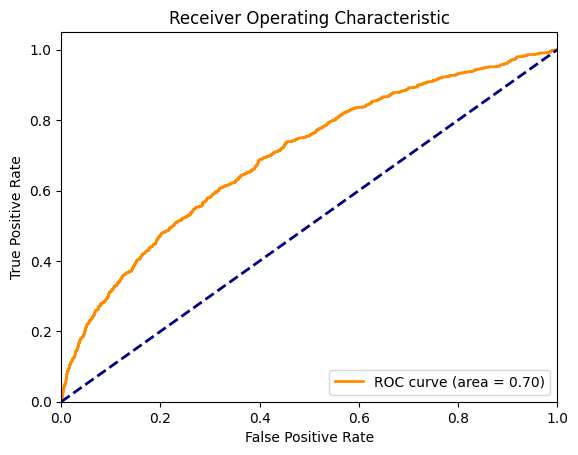

Accuracy: 0.75
Confusion Matrix:
[[7275 2321]
 [ 293  366]]
Classification Report:
              precision    recall  f1-score   support

       False       0.96      0.76      0.85      9596
        True       0.14      0.56      0.22       659

    accuracy                           0.75     10255
   macro avg       0.55      0.66      0.53     10255
weighted avg       0.91      0.75      0.81     10255



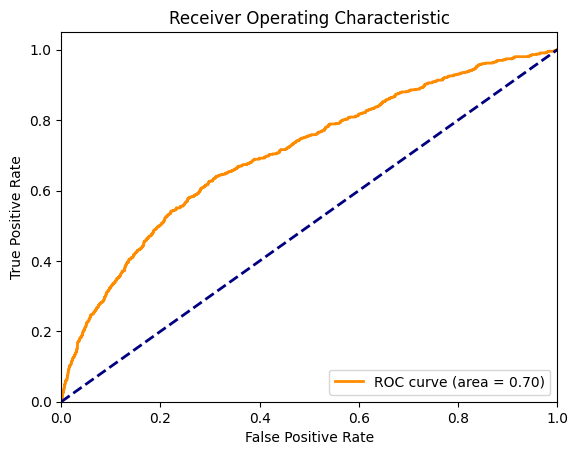

In [ ]:
architectures_4 = [(100, 25), (50, 50), (50), (20, 10, 20,)] #worse, testing smoted version of classifier
for arch in architectures_4:
    model = MLPClassifier(random_state=42, max_iter=10000, hidden_layer_sizes=arch)
    model.fit(X_train_smote, y_binary_train_smote)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    report, roc_auc = performance(y_binary_test, y_pred, y_prob)

    # tokens = report.split()
    # true_precisions.append(float(tokens[10]))
    # true_recalls.append(float(tokens[11]))
    # accs.append(float(tokens[15]))
    # aucs.append(roc_auc)

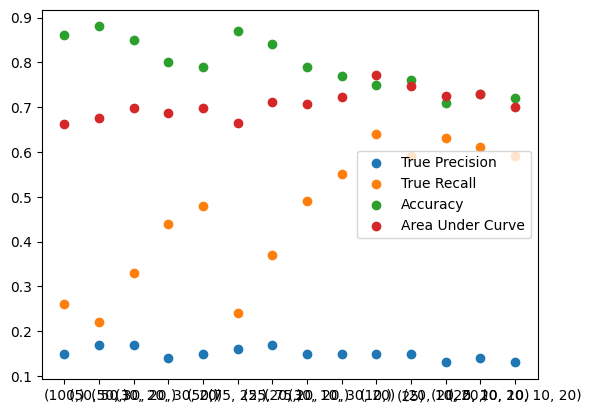

In [ ]:
arch_labels = ["(100,)", "(50, 50,)", "(50, 30, 20,)", "(30, 20, 30, 20)", "(50,)", "(75, 25,)", "(25, 75,)", "(20, 20, 20,)", "(30, 10, 30, 20)", "(10,)", "(25)", "(20, 10, 20,)", "(20, 5, 20, 10)", "(20, 10, 20, 10, 20)"]
plt.scatter(arch_labels[], true_precisions, label = "True Precision")
plt.scatter(arch_labels, true_recalls, label = "True Recall")
plt.scatter(arch_labels, accs, label = "Accuracy")
plt.scatter(arch_labels, aucs, label = "Area Under Curve")
plt.legend()
plt.show()

In [ ]:
a = [(100,), (50, 50,), (50, 30, 20,), (30, 20, 30, 20), (50,), (75, 25,), (25, 75,), (20, 20, 20,), (30, 10, 30, 20), (10,), (25), (20, 10, 20,), (20, 5, 20, 10), (20, 10, 20, 10, 20)]
b = [sum([shape]) for shape in a]

TypeError: unsupported operand type(s) for +: 'int' and 'tuple'

100

In [ ]:
def performance(y_binary_test, y_pred, y_prob, plot=True):
    accuracy = accuracy_score(y_binary_test, y_pred)
    print(f'Accuracy: {accuracy:.2f}')

    cm = confusion_matrix(y_binary_test, y_pred)
    print('Confusion Matrix:')
    print(cm)

    report = classification_report(y_binary_test, y_pred)
    print('Classification Report:')
    print(report)

    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(y_binary_test, y_prob)
    roc_auc = auc(fpr, tpr)

    # Compute PR curve
    # fpr, tpr, thresholds = roc_curve(y_binary_test, y_prob)
    # roc_auc = auc(fpr, tpr)
    prec, rec, thresholds = precision_recall_curve(y_binary_test, y_prob)
    pr_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc='lower right')
    plt.show()

    # Plot PR curve
    plt.figure()
    plt.plot(prec, rec, color='yellow', lw=2, label=f'PR curve (area = {pr_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('precision')
    plt.ylabel('recall')
    plt.title('Precision-Recall Curve')
    plt.legend(loc='lower right')
    plt.show()
    return report, roc_auc